# Project 2: Fraud Check Data
🎯 Objective

Classify customers as:

Risky → Taxable_Income ≤ 30000

Good → Taxable_Income > 30000

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv("Fraud_check.csv")

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(3), object(3)
memory usage: 28.3+ KB


,Taxable.Income,City.Population,Work.Experience
count,600.000000,600.000000,600.000000
mean,55208.375000,108747.368333,15.558333
std,26204.827597,49850.075134,8.842147
min,10003.000000,25779.000000,0.000000
25%,32871.500000,66966.750000,8.000000
50%,55074.500000,106493.500000,15.000000
75%,78611.750000,150114.250000,24.000000
max,99619.000000,199778.000000,30.000000


In [4]:
df['Risk_Status'] = df['Taxable.Income'].apply(
    lambda x: 'Risky' if x <= 30000 else 'Good'
)


In [5]:
df.drop('Taxable.Income', axis=1, inplace=True)


In [6]:
df['Risk_Status'].value_counts()

Risk_Status
Good     476
Risky    124
Name: count, dtype: int64

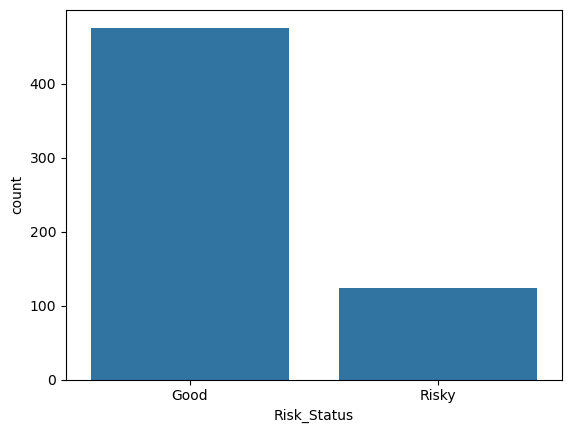

In [7]:
sns.countplot(x='Risk_Status', data=df)
plt.show()

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop('Risk_Status_Risky', axis=1)
y = df['Risk_Status_Risky']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [11]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.76
[[114   3]
 [ 33   0]]
              precision    recall  f1-score   support

       False       0.78      0.97      0.86       117
        True       0.00      0.00      0.00        33

    accuracy                           0.76       150
   macro avg       0.39      0.49      0.43       150
weighted avg       0.60      0.76      0.67       150



# The model effectively classified customers into Risky and Good categories, helping in fraud risk assessment.